# Notebook 7: Outlier Analysis

 Starting Outlier Analysis...
Found 219 Outlier Trades (> 3 Sigma)


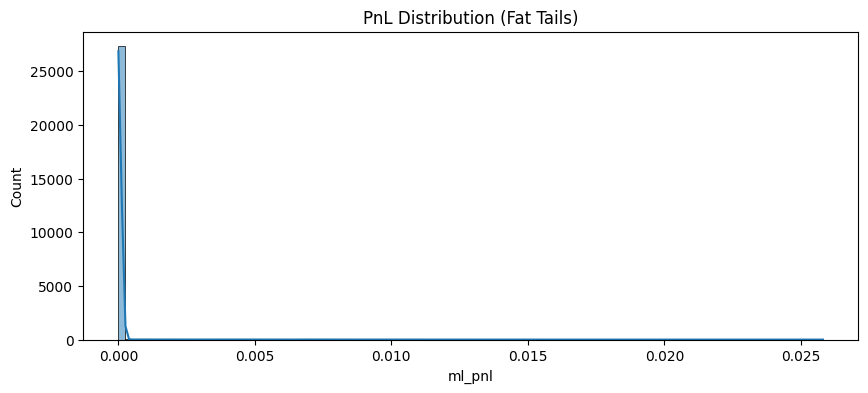

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12188\463738017.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers['hour'] = outliers.index.hour
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12188\463738017.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=outliers['hour'], palette='viridis')


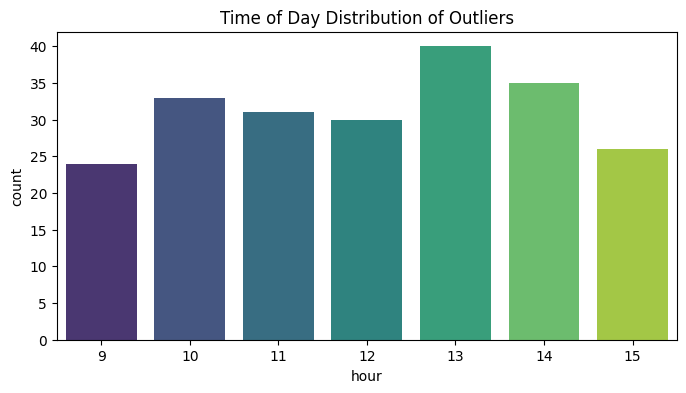

 Analysis Complete. Project Finished!


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print(" Starting Outlier Analysis...")
df = pd.read_csv("../data/nifty_ml_results.csv", index_col='timestamp', parse_dates=True)

# 1. Identify Outliers (Task 6.1)
# Trades with returns > 3 Std Dev
mu = df['ml_pnl'].mean()
sigma = df['ml_pnl'].std()
df['z_score'] = (df['ml_pnl'] - mu) / sigma
outliers = df[df['z_score'] > 3]

print(f"Found {len(outliers)} Outlier Trades (> 3 Sigma)")

# 2. PnL Distribution (Task 6.2)
plt.figure(figsize=(10, 4))
sns.histplot(df['ml_pnl'], bins=100, kde=True)
plt.title("PnL Distribution (Fat Tails)")
plt.savefig("../results/output-6.png")
plt.show()

# 3. Time of Day Analysis (Task 6.3)
# Convert index to datetime if read from CSV
if not pd.api.types.is_datetime64_any_dtype(outliers.index):
    outliers.index = pd.to_datetime(outliers.index)

outliers['hour'] = outliers.index.hour
plt.figure(figsize=(8, 4))
sns.countplot(x=outliers['hour'], palette='viridis')
plt.title("Time of Day Distribution of Outliers")
plt.savefig("../results/output-7.png")
plt.show()

print(" Analysis Complete. Project Finished!")